In [2]:
import nest_asyncio
nest_asyncio.apply()

In [3]:
import numpy as np
import pandas as pd
import kiauhoku as kh
import matplotlib.pyplot as plt
from pathlib import Path

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [4]:
table3_cols=["KIC", "numax", "E_numax", "e_numax", "dnu", "E_dnu", "e_dnu", "Teff", "e_Teff", "[Fe/H]", "e_[Fe/H]", "Ref"]
table3_rows = []
with open("data/apjaa5587t3_mrt.txt", "r") as f:
    for line in f:
        parts = line.split()

        if len(parts) == 12 and parts[0].isdigit():
            table3_rows.append(parts)
table3 = pd.DataFrame(table3_rows, columns=table3_cols)
numeric_cols3 = ["KIC","numax","E_numax","e_numax","dnu","E_dnu","e_dnu","Teff","e_Teff","[Fe/H]","e_[Fe/H]"]
table3[numeric_cols3] = table3[numeric_cols3].apply(pd.to_numeric,errors="coerce")

table4_cols = [
    "KIC", "Mass", "sMassP", "sMassM", "Rad", "sRadP", "sRadM","Grav", "sGravP", "sGravM", "Age", "sAgeP", "sAgeM",
    "Lum", "sLumP", "sLumM", "Rho", "sRhoP", "sRhoM","Dist", "sDistP", "sDistM", "Xini", "sXiniP", "sXiniM","Yini", "sYiniP", 
    "sYiniM", "Xsup", "sXsupP", "sXsupM","Ysup", "sYsupP", "sYsupM", "Xcen", "sXcenP", "sXcenM","Ycen", "sYcenP", 
    "sYcenM", "MCcore", "sMCcoreP", "sMCcoreM","Rbe", "sRbeP", "sRbeM", "alp_conv", "salp_convP", "salp_convM","TAMS"]
table4 = pd.read_csv("data/apjaa5587t4_mrt.txt",comment="#",sep=r"\s+",names=table4_cols)

df = table3.merge(table4,on="KIC",how="inner",validate="one_to_one")

df["mass"] = pd.to_numeric(df["Mass"], errors="coerce")
df["sMassP"] = pd.to_numeric(df["sMassP"], errors="coerce")
df["sMassM"] = pd.to_numeric(df["sMassM"], errors="coerce")
df["e_mass"] = 0.5 * (df["sMassP"].abs() + df["sMassM"].abs())
df["logg"] = pd.to_numeric(df["Grav"], errors="coerce")
df["sGravP"] = pd.to_numeric(df["sGravP"], errors="coerce")
df["sGravM"] = pd.to_numeric(df["sGravM"], errors="coerce")
df["e_logg"] = 0.5 * (df["sGravP"].abs() + df["sGravM"].abs())
df["teff"] = pd.to_numeric(df["Teff"], errors="coerce")
df["e_teff"] = pd.to_numeric(df["e_Teff"],errors="coerce").abs()
df["fe/h"] = pd.to_numeric(df["[Fe/H]"],errors="coerce")
df["e_fe/h"] = pd.to_numeric(df["e_[Fe/H]"],errors="coerce").abs()
df["age"] = pd.to_numeric(df["Age"], errors="coerce")
df["sAgeP"] = pd.to_numeric(df["sAgeP"], errors="coerce")
df["sAgeM"] = pd.to_numeric(df["sAgeM"], errors="coerce")
df["e_age"] = 0.5 * (df["sAgeP"].abs() + df["sAgeM"].abs())

needed_cols = ["KIC","mass","e_mass","logg","e_logg","teff","e_teff","fe/h","e_fe/h","age","e_age"]
df[needed_cols] = df[needed_cols].replace(-999, np.nan)
good = np.isfinite(df[needed_cols].to_numpy(dtype=float)).all(axis=1)
apokasc = df.loc[good, needed_cols].reset_index(drop=True)
sample = apokasc.sample(n=66, random_state=42).reset_index(drop=True)

In [17]:
def lnprior(theta):
    mass, met, eep = theta  
    return 0

def lnlike(theta, grid, data, sigma):
    mass, met, eep = theta  
    #print(theta)
    star = grid.get_star_eep(theta)
    if star.isnull().any():
        return -np.inf, None

    #teff = 10**star['Log Teff(K)']
    teff = 10.**(star['log_Teff']) 
    star['Teff(K)'] = teff

    # z_x_surf = np.log10(star['Z/X(surf)']/0.02289)
    z_x_surf = star['log_surf_z'] - np.log10(0.02289)
    star['[Z/X]'] = z_x_surf
    #star['[alpha/Z]'] = alpha 
    star['alpha/Z'] = 0.0
    star['Age(Gyr)'] = star['star_age']/1e9 # age in Gyr
    log_g = star['log_g'] 
    #print(star['log_g'])
    star['initial mass'] = mass
    star['initial [M/H]'] = met
    star['initial [alpha/M]'] = 0.0#alpha

    # theta_ = np.array([teff, z_x_surf, 0.0, log_g]) 
    theta_ = np.array([teff, z_x_surf, 0.0, log_g]) 
    my_log_like = lnChiSq(theta_, data, sigma)
    return my_log_like, star


def lnChiSq(theta, data, sigma):
    return -0.5 * (((theta-data)/sigma)**2).sum()

In [16]:
def lnprob(theta, grid, data, sigma):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf, None

    ll, star = lnlike(theta, grid, data, sigma)

    if not np.isfinite(ll):
        return -np.inf, None

    my_log_prob = lp + ll
    star["lnprob"] = my_log_prob

    return my_log_prob, star

In [ ]:
n_walkers = 12
n_burnin = 1000
n_iter = 3000

grid = kh.load_interpolator('mist')

for _, row in sample.iterrows():
    kic = int(row["KIC"])
    
    #data = np.array([6000, 0, 0, 3.7])
    #sigma = np.array([10, 0.01, 0.1, 0.005])
    data = np.array([row["teff"],row["fe/h"],0,row["logg"]], dtype=float)
    # proper way w/ aplha err
    sigma = np.array([row["e_teff"],row["e_fe/h"],0.1,row["e_logg"]], dtype=float)
    args = (data, sigma)
    
    #initial_guess = (1, 0, 450) 
    #guess_width = (2, 0.1, 10)
    initial_guess = (float(row["mass"]),float(row["fe/h"]),450.0)
    guess_width = (1, 0.1, 10.0)
    
    sampler, chains = grid.mcmc_star(
        lnprob, args,
        initial_guess=initial_guess,
        guess_width=guess_width,
        n_walkers=n_walkers,
        n_burnin=n_burnin,
        n_iter=n_iter,
    )
    
    chains.to_csv(f"dwarf_no_m_run_saves/dwarf_no_m_run_{kic}.csv", index=False)

100%|██████████| 3000/3000 [01:29<00:00, 33.53it/s]


In [ ]:
from corner import corner

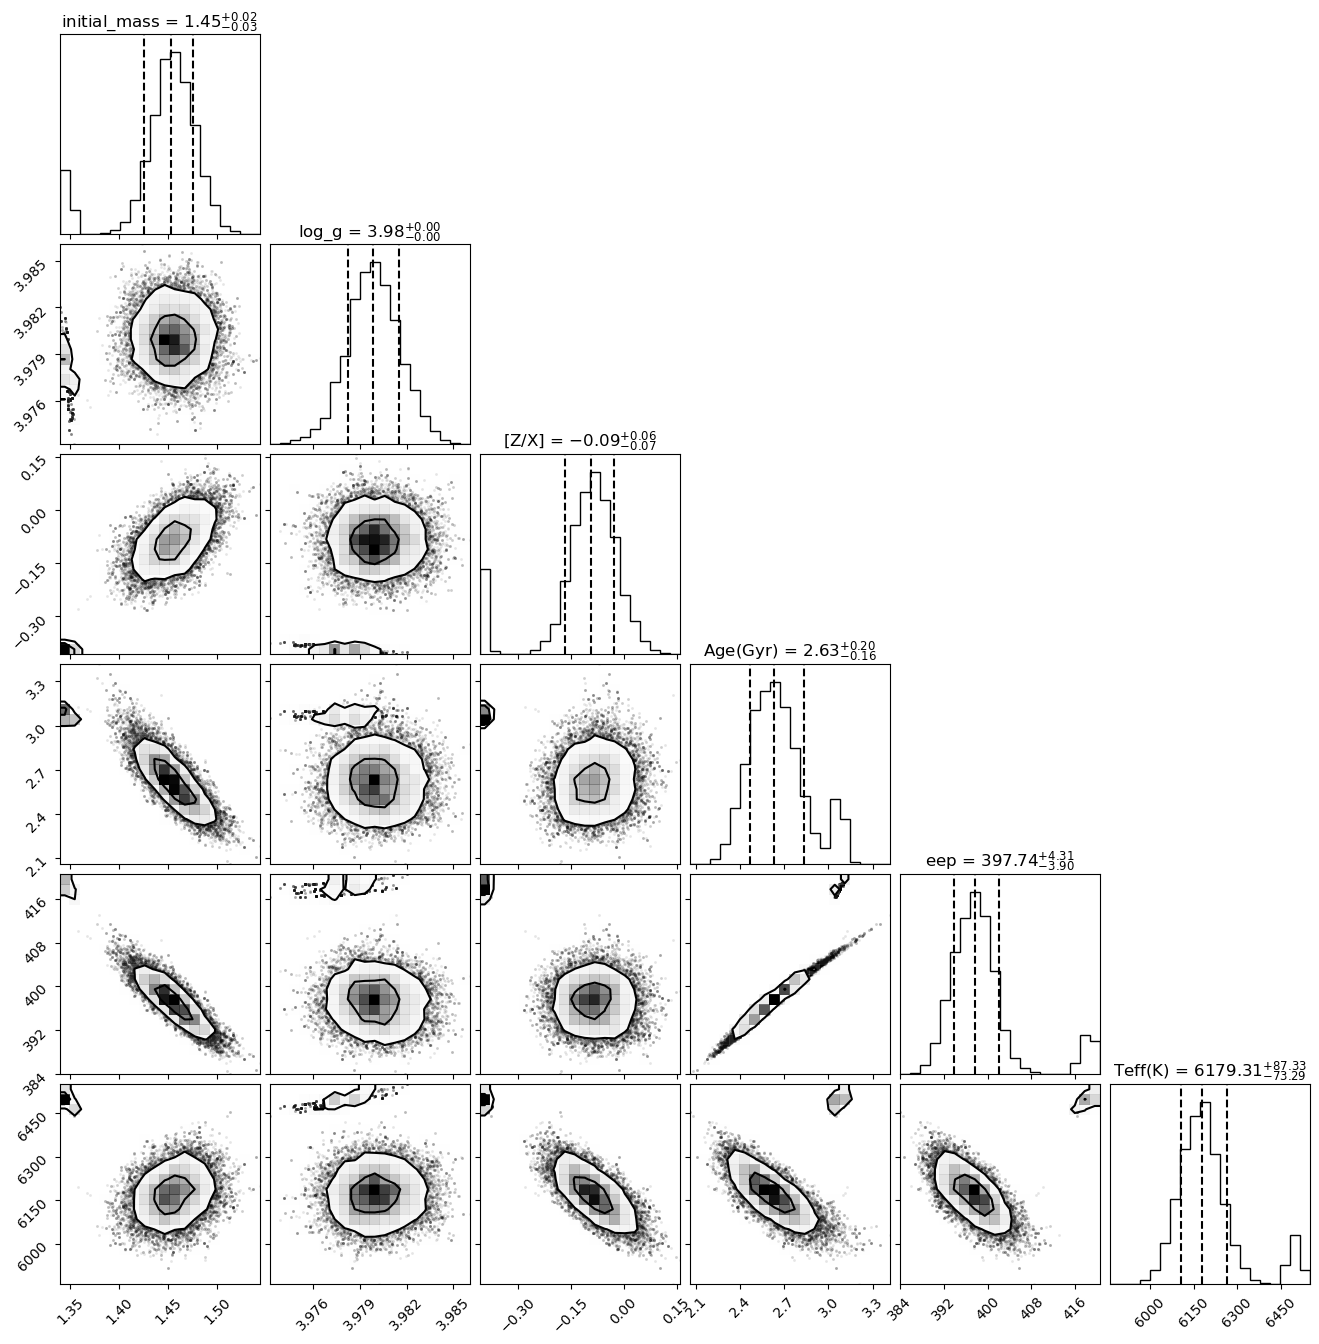

In [ ]:
labels = ['initial mass', 'initial [M/H]', 'initial [alpha/M]', 'logg',
    'Age(Gyr)', 'Teff(K)', 'L/Lsun', 'R/Rsun']
labels = ['initial_mass', 'log_g', '[Z/X]', 'Age(Gyr)', 'eep', 'Teff(K)']
fig = corner(chains[labels], show_titles=True, titles=labels,
    quantiles=(0.16, 0.5, 0.84), levels=(1-np.exp(-2), 1-np.exp(-0.5)))

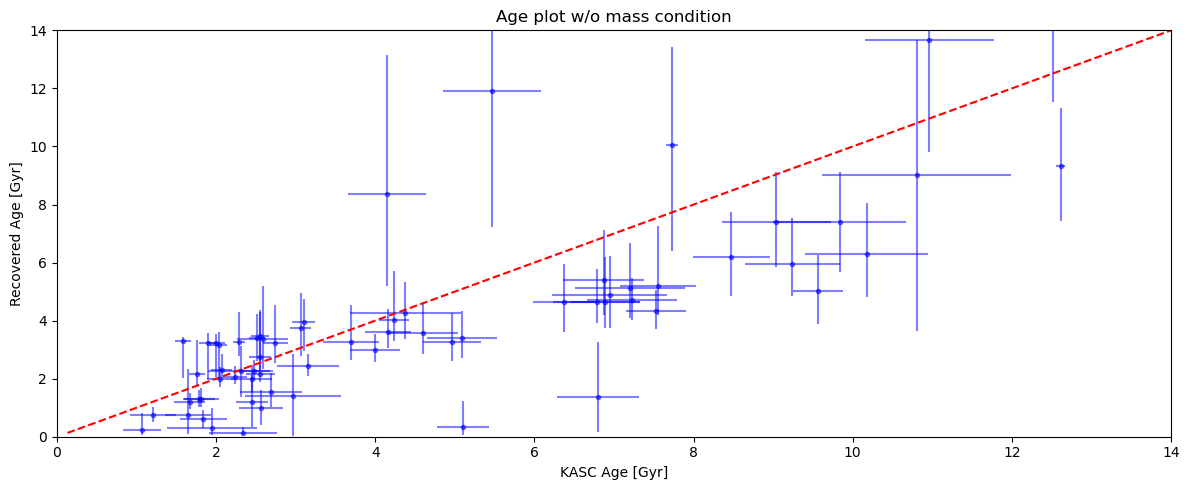

In [15]:
files = sorted(Path("dwarf_no_m_run_saves").glob("dwarf_no_m_run_*.csv"))

run_results = []

for file in files:
    run = pd.read_csv(file)
    run.columns = run.columns.str.strip()

    run_id = int(file.stem.replace("dwarf_no_m_run_", ""))
    kic = run_id
    
    if "Age(Gyr)" in run.columns:
        age_col = "Age(Gyr)"
    elif "star_age" in run.columns:
        run["Age(Gyr)"] = run["star_age"] / 1e9
        age_col = "Age(Gyr)"
    else:
        continue

    age_vals = pd.to_numeric(run[age_col], errors="coerce")
    age_vals = age_vals[np.isfinite(age_vals)]
    if age_vals.empty:
        continue
    age_16, age_50, age_84 = np.percentile(age_vals, [16, 50, 84])

    run_results.append({"KIC": kic,
    "mcmc_age": age_50, "mcmc_age_err_low": age_50 - age_16, "mcmc_age_err_high": age_84 - age_50})

new_results= pd.DataFrame(run_results)

observed = sample[["KIC", "age", "e_age"]].drop_duplicates(subset="KIC")

comparison = observed.merge(new_results, on="KIC", how="inner")
if comparison.empty:
    raise ValueError("No overlapping KICs between sample and recovered ages.")
comparison["age_diff"] = (comparison["mcmc_age"] - comparison["age"])

age_min = min(comparison["age"].min(),comparison["mcmc_age"].min())
age_max = max(comparison["age"].max(),comparison["mcmc_age"].max())
age_bias = (comparison["mcmc_age"] - comparison["age"]).mean()

fig, ax = plt.subplots(1, figsize=(12, 5))

# individual and error bars
ax.errorbar(comparison["age"],comparison["mcmc_age"], xerr=comparison["e_age"], 
yerr=np.vstack([comparison["mcmc_age_err_low"], comparison["mcmc_age_err_high"]]), 
fmt="o", color="blue", alpha=0.5, markersize=3)
ax.set_xlim([0,14])
ax.set_ylim([0,14])

# offset
age_offset = comparison["age_diff"].mean()
#axes.plot([age_min, age_max],[age_min + age_bias, age_max + age_bias],"--", color = "black",
          #label=f"Mean offset = {age_bias:.2f} Gyr")

# standard deviation
age_std = comparison["age_diff"].std()
# +1
# axes.plot([age_min, age_max],[age_min + age_offset + age_std,age_max + age_offset + age_std],
#    ":",color="black",label=f"±1sigma = {age_std:.2f} Gyr")
# -1
# axes.plot([age_min, age_max],[age_min + age_offset - age_std,age_max + age_offset - age_std],
#    ":",color="black")

# 1-1 line
ax.plot([age_min, age_max],[age_min, age_max],"--",color="red",label="1:1")

ax.set_xlabel("KASC Age [Gyr]")
ax.set_ylabel("Recovered Age [Gyr]")
ax.set_title("Age plot w/o mass condition")

plt.tight_layout()
plt.show()

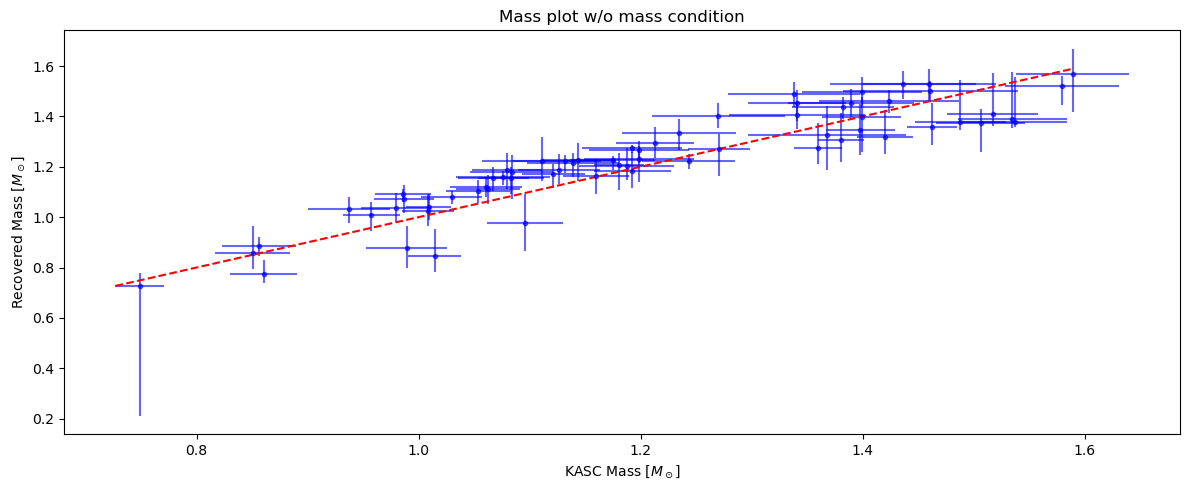

In [13]:
files = sorted(Path("dwarf_no_m_run_saves").glob("dwarf_no_m_run_*.csv"))

run_results = []

for file in files:
    run = pd.read_csv(file)
    run.columns = run.columns.str.strip()

    run_id = int(file.stem.replace("dwarf_no_m_run_", ""))
    kic = run_id
    
    if "initial_mass" in run.columns:
        mass_col = "initial_mass"
    elif "mass" in run.columns:
        mass_col = "mass"
    elif "star_mass" in run.columns:
        run["initial_mass"] = run["star_mass"]
        mass_col = "initial_mass"
    else:
        continue
        
    mass_vals = run[mass_col].dropna()
    if mass_vals.empty:
        continue

    m_16, m_50, m_84 = np.percentile(mass_vals,[16, 50, 84])

    run_results.append({"KIC": kic,
    "mcmc_mass": m_50, "mcmc_mass_err_low": m_50 - m_16, "mcmc_mass_err_high": m_84 - m_50})

new_results= pd.DataFrame(run_results)

observed = sample[["KIC", "mass", "e_mass"]].drop_duplicates(subset="KIC").copy()
comparison = observed.merge(new_results, on="KIC", how="inner")
if comparison.empty:
    raise ValueError("No overlapping KICs between sample and recovered masses.")
comparison["mass_diff"] = comparison["mcmc_mass"] - comparison["mass"]

mass_min = comparison[["mass","mcmc_mass"]].min().min()
mass_max = comparison[["mass","mcmc_mass"]].max().max()
mass_mean = comparison["mass_diff"].mean()
mass_std = comparison["mass_diff"].std(ddof=0)


fig, ax = plt.subplots(1, figsize=(12, 5))

# individual and exxort bars
ax.errorbar(comparison["mass"],comparison["mcmc_mass"],
xerr=comparison["e_mass"],yerr=np.vstack([comparison["mcmc_mass_err_low"], comparison["mcmc_mass_err_high"]]),
fmt="o", color="blue", alpha=0.6, markersize=3)

# offset
mass_offset = comparison["mass_diff"].mean()
#axes.plot([mass_min, mass_max],[mass_min + mass_bias, mass_max + mass_bias],"--", color = "black",
          #label=f"Mean offset = {age_bias:.2f} Gyr")

# standard deviation
mass_std = comparison["mass_diff"].std()
# +1
# axes.plot([mass_min, mass_max],[mass_min + mass_offset + mass_std,mass_max + mass_offset + mass_std],
#    ":",color="black",label=f"±1sigma = {mass_std:.2f} Gyr")
# -1
# axes.plot([mass_min, mass_max],[mass_min + mass_offset - mass_std,mass_max + mass_offset - mass_std],
 #   ":",color="black")

# 1-1 line
ax.plot([mass_min, mass_max],[mass_min, mass_max],"--",color="red",label="1:1")


ax.set_xlabel("KASC Mass [$M_\odot$]")
ax.set_ylabel("Recovered Mass [$M_\odot$]")
ax.set_title("Mass plot w/o mass condition")

plt.tight_layout()
plt.show()